# Tahap 1: Preprocessing & Feature Engineering
Notebook ini berfokus pada tiga tahapan utama untuk mempersiapkan data mentah Posyandu sebelum dilatih oleh Machine Learning:

1. **Pembersihan Data (Preprocessing):** Meratakan struktur data dari format Excel (*MultiIndex*) dan memfilter anomali nilai yang kosong.
2. **Rekayasa Fitur (Feature Engineering):** Mengekstrak fitur Kecepatan_Tumbuh (Tinggi dan Berat) secara dinamis. Ini memungkinkan model mendeteksi gejala awal gagal tumbuh (*Faltering Growth*) secara independen dari jumlah bulan pantauan.
3. **Simulasi Parametrik & Augmentasi Data:** Menyuntikkan 500 profil pasien virtual (250 Normal, 250 Stunting) dengan korelasi klinis yang terkunci sesuai standar WHO. Setelah itu, metode **SMOTE** digunakan untuk menyeimbangkan sedikit selisih data, menghasilkan sekitar 602 baris dataset final yang sangat *robust* secara medis.

In [18]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

### 1. Load Data

In [19]:
raw_data_path = '../data/raw/dataset_posyandu.xlsx'
df = pd.read_excel(raw_data_path, header=[0, 1])

# Gabungkan multi-level header menjadi satu baris
new_cols = []
for c in df.columns:
    if 'Unnamed' in str(c[1]):
        new_cols.append(c[0])
    elif 'Unnamed' in str(c[0]):
        new_cols.append(c[1])
    else:
        new_cols.append(f"{c[0]}_{c[1]}")
df.columns = new_cols
df.head(3)

,No,Nama,Umur (Bulan),Jenis Kelamin,OrangTua,Alamat (Dusun),January_BB(kg),January_TB(cm),February_BB(kg),February_TB(cm),March_BB(kg),March_TB(cm),April_BB(kg),April_TB(cm),May_BB(kg),May_TB(cm),NORMAL(0) STUNTING (1)
0,1,CHAIRUNISA SALSABILA PUTRI,27,P,NaN,PAHING,10.8,81.7,11.1,82.4,11,83.0,10.80,84.0,11.2,86.0,0
1,2,DEANDRA ALFATHUNISA SYAFAZEA,36,P,NaN,PAHING,10.3,83.6,10.4,83.6,10.4,84.6,10.80,86.8,11.0,87.0,1
2,3,ARLEYAVA EVELYN PERMANA P,18,P,NaN,PAHING,8.0,72.0,8.4,73.0,8.5,73.6,8.67,74.3,9.0,75.0,1


### 2. Exploratory Data Analysis (EDA)

In [20]:
# Cek Missing Values
print("=== Pengecekan Missing Values ===")
print(df.isnull().sum())
print("\n")


=== Pengecekan Missing Values ===
No                         0
Nama                       0
Umur (Bulan)               0
Jenis Kelamin              0
OrangTua                  71
Alamat (Dusun)             0
January_BB(kg)             0
January_TB(cm)             0
February_BB(kg)            0
February_TB(cm)            0
March_BB(kg)               0
March_TB(cm)               0
April_BB(kg)               0
April_TB(cm)               0
May_BB(kg)                 0
May_TB(cm)                 0
NORMAL(0) STUNTING (1)     0
dtype: int64




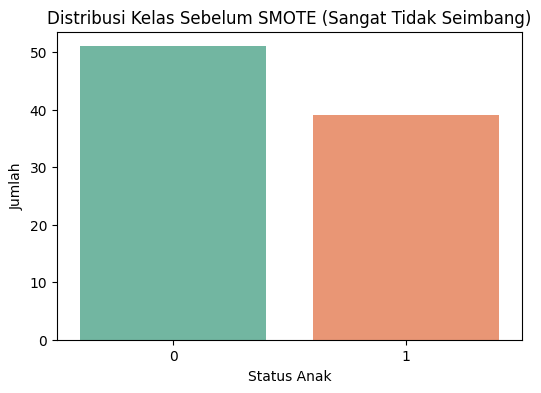

In [21]:
# Visualisasi Ketidakseimbangan Kelas (Class Imbalance)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='NORMAL(0) STUNTING (1)', palette='Set2')
plt.title('Distribusi Kelas Sebelum SMOTE (Sangat Tidak Seimbang)')
plt.xlabel('Status Anak')
plt.ylabel('Jumlah')
plt.show()

### 3. Pembersihan Data

In [22]:
# Buang kolom identitas pasien
cols_to_drop = ['No', 'Nama', 'OrangTua', 'Alamat (Dusun)']
df_bersih = df.drop(columns=cols_to_drop, errors='ignore')

# Hapus baris kosong
df_bersih = df_bersih.dropna(how='all')
df_bersih.head(3)

,Umur (Bulan),Jenis Kelamin,January_BB(kg),January_TB(cm),February_BB(kg),February_TB(cm),March_BB(kg),March_TB(cm),April_BB(kg),April_TB(cm),May_BB(kg),May_TB(cm),NORMAL(0) STUNTING (1)
0,27,P,10.8,81.7,11.1,82.4,11,83.0,10.80,84.0,11.2,86.0,0
1,36,P,10.3,83.6,10.4,83.6,10.4,84.6,10.80,86.8,11.0,87.0,1
2,18,P,8.0,72.0,8.4,73.0,8.5,73.6,8.67,74.3,9.0,75.0,1


### 4. Feature Engineering Dinamis (Kecepatan Tumbuh)


In [23]:
bb_cols = [c for c in df_bersih.columns if 'BB' in c]
tb_cols = [c for c in df_bersih.columns if 'TB' in c]

# Ambil nilai awal dan akhir dari riwayat pengukuran
df_bersih['BB_Awal'] = df_bersih[bb_cols[0]]
df_bersih['TB_Awal'] = df_bersih[tb_cols[0]]
df_bersih['BB_Akhir'] = df_bersih[bb_cols[-1]]
df_bersih['TB_Akhir'] = df_bersih[tb_cols[-1]]

# Lama pantau dihitung dari jumlah kolom histori yang tersedia
df_bersih['Lama_Pantau_Bulan'] = len(bb_cols)

# Hitung kecepatan tumbuh per bulan (menghindari pembagian nol)
interval = df_bersih['Lama_Pantau_Bulan'] - 1
interval = interval.replace(0, 1) # Fallback jika hanya 1 bulan

df_bersih['Kecepatan_Tumbuh_BB'] = (df_bersih['BB_Akhir'] - df_bersih['BB_Awal']) / interval
df_bersih['Kecepatan_Tumbuh_TB'] = (df_bersih['TB_Akhir'] - df_bersih['TB_Awal']) / interval

df_bersih['Rasio_BB_TB_Akhir'] = df_bersih['BB_Akhir'] / (df_bersih['TB_Akhir'] + 0.001)

# Encoding Jenis Kelamin menjadi Numerik (L=1, P=0) agar bisa dibaca model ML
df_bersih['Jenis Kelamin'] = df_bersih['Jenis Kelamin'].map({'L': 1, 'P': 0})

# Seleksi hanya kolom fitur yang akan dipakai model
final_columns = ['Umur (Bulan)', 'Jenis Kelamin', 'BB_Awal', 'TB_Awal', 'BB_Akhir', 'TB_Akhir', 
                 'Lama_Pantau_Bulan', 'Kecepatan_Tumbuh_BB', 'Kecepatan_Tumbuh_TB', 'Rasio_BB_TB_Akhir', 'Status']

# Asumsi kolom target mengandung kata NORMAL atau STUNTING
target_col = [c for c in df_bersih.columns if 'NORMAL' in c.upper() or 'STUNTING' in c.upper()][0]
df_bersih = df_bersih.rename(columns={target_col: 'Status'})

df_fitur = df_bersih[final_columns]
df_fitur.head(3)

,Umur (Bulan),Jenis Kelamin,BB_Awal,TB_Awal,BB_Akhir,TB_Akhir,Lama_Pantau_Bulan,Kecepatan_Tumbuh_BB,Kecepatan_Tumbuh_TB,Rasio_BB_TB_Akhir,Status
0,27,0,10.8,81.7,11.2,86.0,5,0.100,1.075,0.130231,0
1,36,0,10.3,83.6,11.0,87.0,5,0.175,0.850,0.126435,1
2,18,0,8.0,72.0,9.0,75.0,5,0.250,0.750,0.119998,1


### 5. Injeksi Data Klinis Buatan

In [24]:
# Hapus baris kosong jika ada
df_fitur = df_fitur.dropna()

import numpy as np
import pandas as pd

# Fungsi untuk mendapatkan batas bawah tinggi normal (WHO)
def get_stunting_threshold(age):
    if age <= 5: return 60
    elif age <= 11: return 68
    elif age <= 17: return 75
    elif age <= 23: return 80
    elif age <= 35: return 85
    elif age <= 47: return 93
    else: return 99

np.random.seed(42)
num_normal = 250
num_stunting = 250

# --- GENERATE NORMAL (0) ---
umur_normal = np.random.randint(3, 61, num_normal)
tb_akhir_normal = [np.round(np.random.uniform(get_stunting_threshold(a) + 1, get_stunting_threshold(a) + 15), 1) for a in umur_normal]
bb_akhir_normal = [np.round(tb * np.random.uniform(0.12, 0.16), 1) for tb in tb_akhir_normal]
kec_tb_normal = np.round(np.random.uniform(0.5, 1.5, num_normal), 2)
kec_bb_normal = np.round(np.random.uniform(0.1, 0.3, num_normal), 2)
lama_pantau_normal = np.random.choice([3, 4, 5, 6], num_normal)

# --- GENERATE STUNTING (1) ---
umur_stunting = np.random.randint(3, 61, num_stunting)
tb_akhir_stunting = [np.round(np.random.uniform(get_stunting_threshold(a) - 10, get_stunting_threshold(a) - 0.1), 1) for a in umur_stunting]
bb_akhir_stunting = [np.round(tb * np.random.uniform(0.11, 0.14), 1) for tb in tb_akhir_stunting]
kec_tb_stunting = np.round(np.random.uniform(0.0, 0.5, num_stunting), 2)
kec_bb_stunting = np.round(np.random.uniform(0.0, 0.1, num_stunting), 2)
lama_pantau_stunting = np.random.choice([3, 4, 5, 6], num_stunting)

# --- GABUNGKAN KE DATAFRAME ---
df_normal = pd.DataFrame({
    'Umur (Bulan)': umur_normal,
    'Jenis Kelamin': np.random.choice([0, 1], num_normal),
    'Lama_Pantau_Bulan': lama_pantau_normal,
    'Kecepatan_Tumbuh_BB': kec_bb_normal,
    'Kecepatan_Tumbuh_TB': kec_tb_normal,
    'TB_Akhir': tb_akhir_normal,
    'BB_Akhir': bb_akhir_normal,
    'Status': 0
})

df_stunting = pd.DataFrame({
    'Umur (Bulan)': umur_stunting,
    'Jenis Kelamin': np.random.choice([0, 1], num_stunting),
    'Lama_Pantau_Bulan': lama_pantau_stunting,
    'Kecepatan_Tumbuh_BB': kec_bb_stunting,
    'Kecepatan_Tumbuh_TB': kec_tb_stunting,
    'TB_Akhir': tb_akhir_stunting,
    'BB_Akhir': bb_akhir_stunting,
    'Status': 1
})

# Menghitung Nilai Awal dan Rasio untuk melengkapi Fitur (Korelasi Fisik Terkunci)
for df_sim in [df_normal, df_stunting]:
    interval = df_sim['Lama_Pantau_Bulan'] - 1
    df_sim['TB_Awal'] = np.round(df_sim['TB_Akhir'] - (df_sim['Kecepatan_Tumbuh_TB'] * interval), 1)
    df_sim['BB_Awal'] = np.round(df_sim['BB_Akhir'] - (df_sim['Kecepatan_Tumbuh_BB'] * interval), 1)
    df_sim['Rasio_BB_TB_Akhir'] = df_sim['BB_Akhir'] / df_sim['TB_Akhir']

# Urutkan kolom sesuai dataset asli
cols_order = ['Umur (Bulan)', 'Jenis Kelamin', 'BB_Awal', 'TB_Awal', 'BB_Akhir', 'TB_Akhir', 'Lama_Pantau_Bulan', 'Kecepatan_Tumbuh_BB', 'Kecepatan_Tumbuh_TB', 'Rasio_BB_TB_Akhir', 'Status']
df_normal = df_normal[cols_order]
df_stunting = df_stunting[cols_order]

# Gabungkan profil buatan ke dataset asli SEBELUM diserahkan ke SMOTE
df_fitur = pd.concat([df_fitur, df_normal, df_stunting], ignore_index=True)
print(f"Berhasil menyuntikkan {num_normal} pasien Normal dan {num_stunting} pasien Stunting buatan ke dataset!")


Berhasil menyuntikkan 250 pasien Normal dan 250 pasien Stunting buatan ke dataset!


### 6. Penyeimbangan Data Dinamis dengan SMOTE

In [25]:
X = df_fitur.drop(columns=['Status'])
y = df_fitur['Status']

print("Distribusi kelas SEBELUM SMOTE:")
print(y.value_counts())

# Inisialisasi SMOTE (Hanya akan menyamakan jumlah minoritas ke mayoritas)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Gabungkan hasil ke DataFrame final
df_final = pd.concat([X_resampled, y_resampled], axis=1)

# Acak urutan agar Normal dan Stunting bercampur
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribusi kelas SESUDAH SMOTE:")
print(df_final['Status'].value_counts())
print(f"\nTotal Data Latih Siap Pakai: {len(df_final)} baris")


Distribusi kelas SEBELUM SMOTE:
Status
0    301
1    289
Name: count, dtype: int64

Distribusi kelas SESUDAH SMOTE:
Status
0    301
1    301
Name: count, dtype: int64

Total Data Latih Siap Pakai: 602 baris


### 7. Visualisasi Hasil SMOTE (EDA)

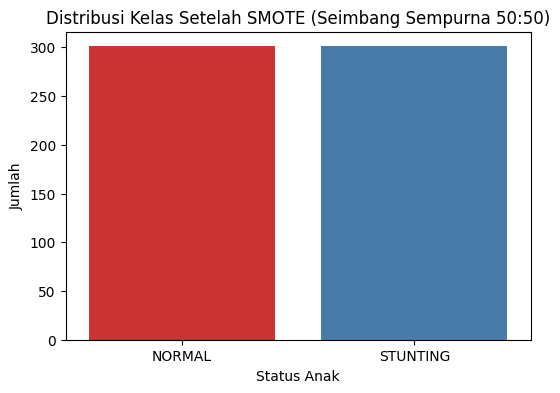

Total data sekarang: 602 baris


In [26]:
plt.figure(figsize=(6, 4))
# Mengubah y_resampled menjadi DataFrame sementara untuk visualisasi
df_resampled = pd.DataFrame({'Status': y_resampled})
df_resampled['Status_Label'] = df_resampled['Status'].map({0: 'NORMAL', 1: 'STUNTING'})

sns.countplot(data=df_resampled, x='Status_Label', palette='Set1')
plt.title('Distribusi Kelas Setelah SMOTE (Seimbang Sempurna 50:50)')
plt.xlabel('Status Anak')
plt.ylabel('Jumlah')
plt.show()

print(f"Total data sekarang: {len(X_resampled)} baris")


### 8. Simpan Dataset

In [27]:
# Simpan ke folder processed
df_final.to_csv('../data/processed/dataset_final_training.csv', index=False)
print("Data training SMOTE berhasil disimpan ke 'data/processed/dataset_final_training.csv'")
df_final.head()


Data training SMOTE berhasil disimpan ke 'data/processed/dataset_final_training.csv'


,Umur (Bulan),Jenis Kelamin,BB_Awal,TB_Awal,BB_Akhir,TB_Akhir,Lama_Pantau_Bulan,Kecepatan_Tumbuh_BB,Kecepatan_Tumbuh_TB,Rasio_BB_TB_Akhir,Status
0,55,0,14.8,109.8,15.4,111.7,4,0.19,0.65,0.137869,0
1,24,1,10.0,78.8,10.4,80.6,5,0.10,0.45,0.129032,1
2,43,1,9.7,85.6,10.0,86.8,4,0.09,0.41,0.115207,1
3,55,0,11.0,98.0,12.2,98.0,5,0.30,0.00,0.124489,1
4,33,0,10.5,88.1,11.0,89.9,3,0.24,0.89,0.122358,0
